In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    average_precision_score,
    precision_recall_curve
)

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import save_model

import warnings
warnings.filterwarnings('ignore')


Load dữ liệu

In [2]:

train_ffnn_df = pd.read_csv("../data/processed/train_under.csv")
train_ae_df = pd.read_csv("../data/processed/train_original.csv")
test_df = pd.read_csv("../data/processed/test.csv")

print("FFNN train:", train_ffnn_df.shape)
print("AE train:", train_ae_df.shape)
print("Test:", test_df.shape)

FFNN train: (22995, 17)
AE train: (5090096, 17)
Test: (1272524, 17)


Tách Features và Labels

In [3]:
X_train_ffnn = train_ffnn_df.drop("isFraud", axis=1)
y_train_ffnn = train_ffnn_df["isFraud"]

X_train_ae = train_ae_df.drop("isFraud", axis=1)
y_train_ae = train_ae_df["isFraud"]

X_test = test_df.drop("isFraud", axis=1)
y_test = test_df["isFraud"]

print("X_train_ffnn:", X_train_ffnn.shape)
print("X_train_ae:", X_train_ae.shape)
print("X_test:", X_test.shape)

X_train_ffnn: (22995, 16)
X_train_ae: (5090096, 16)
X_test: (1272524, 16)


In [4]:
X_train_ffnn = X_train_ffnn.astype("float32")
y_train_ffnn = y_train_ffnn.astype("int32")

X_train_ae = X_train_ae.astype("float32")
y_train_ae = y_train_ae.astype("int32")

X_test = X_test.astype("float32")
y_test = y_test.astype("int32")

In [5]:
def plot_training_history(history, model_name):
    plt.figure(figsize=(7, 5))
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"Training vs Validation Loss - {model_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

FFNN

Epoch 1/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.8946 - auc: 0.5610 - loss: 0.4389 - precision: 0.5941 - recall: 0.0512 - val_accuracy: 0.2170 - val_auc: 0.0000e+00 - val_loss: 1.4501 - val_precision: 1.0000 - val_recall: 0.2170
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9237 - auc: 0.8435 - loss: 0.2383 - precision: 0.9896 - recall: 0.2907 - val_accuracy: 0.5414 - val_auc: 0.0000e+00 - val_loss: 1.1038 - val_precision: 1.0000 - val_recall: 0.5414
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9498 - auc: 0.9313 - loss: 0.1632 - precision: 0.9556 - recall: 0.5571 - val_accuracy: 0.6599 - val_auc: 0.0000e+00 - val_loss: 0.7947 - val_precision: 1.0000 - val_recall: 0.6599
Epoch 4/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9616 - auc: 0.9643 - loss: 0.1244 - precision: 0.9438 - recall: 0.6819 - val_accuracy: 0.7602 - val_auc: 0.0000e+00 - val_loss: 0.6178 - val_precision: 1.0000 - val_recall: 0.7602
Epoch 5/30
18/18 ━━━

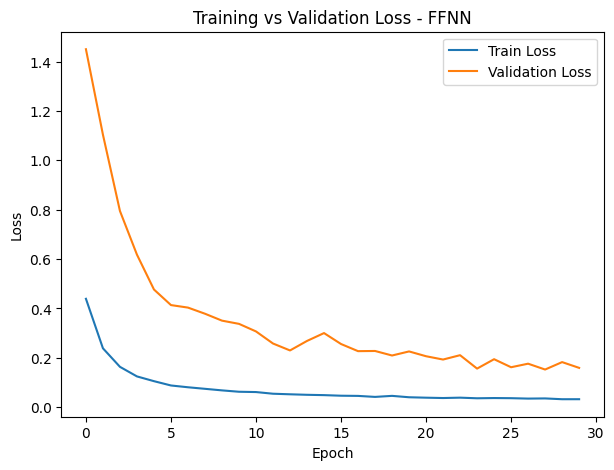


FFNN final train loss: 0.032076507806777954
FFNN final val loss: 0.15905937552452087
39767/39767 ━━━━━━━━━━━━━━━━━━━━ 40s 1ms/step


In [6]:

input_dim = X_train_ffnn.shape[1]

ffnn_model = Sequential([
    Input(shape=(input_dim,)),

    Dense(128, activation="relu"),
    Dropout(0.3),

    Dense(64, activation="relu"),
    Dropout(0.3),

    Dense(32, activation="relu"),

    Dense(1, activation="sigmoid")
])

ffnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_ffnn = ffnn_model.fit(
    X_train_ffnn,
    y_train_ffnn,
    validation_split=0.2,
    epochs=30,
    batch_size=1024,
    callbacks=[early_stop],
    verbose=1
)


# FFNN OVERFITTING CHECK

plot_training_history(history_ffnn, "FFNN")

print("\nFFNN final train loss:", history_ffnn.history["loss"][-1])
print("FFNN final val loss:", history_ffnn.history["val_loss"][-1])


# FFNN PREDICTION

y_prob_ffnn = ffnn_model.predict(X_test).flatten()

threshold_ffnn = 0.75

y_pred_ffnn = (y_prob_ffnn >= threshold_ffnn).astype(int)

AutoEncoder

In [7]:

X_train_normal = X_train_ae[y_train_ae == 0]

print("Normal train shape:", X_train_normal.shape)

Normal train shape: (5083526, 16)


Epoch 1/30
3972/3972 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - loss: 0.0059 - val_loss: 0.0068
Epoch 2/30
3972/3972 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - loss: 0.0013 - val_loss: 3.2295e-04
Epoch 3/30
3972/3972 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - loss: 0.0011 - val_loss: 1.6419e-04
Epoch 4/30
3972/3972 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - loss: 0.0012 - val_loss: 0.0031
Epoch 5/30
3972/3972 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - loss: 7.5880e-04 - val_loss: 1.7216e-04
Epoch 6/30
3972/3972 ━━━━━━━━━━━━━━━━━━━━ 27s 6ms/step - loss: 5.1268e-04 - val_loss: 1.2991e-04
Epoch 7/30
3972/3972 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - loss: 6.2066e-04 - val_loss: 1.9776e-04
Epoch 8/30
3972/3972 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - loss: 6.2757e-04 - val_loss: 2.8992e-04
Epoch 9/30
3972/3972 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - loss: 5.1639e-04 - val_loss: 8.5040e-05
Epoch 10/30
3972/3972 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - loss: 4.6056e-04 - val_loss: 0.0017
Epoch 11/30
3972/3972 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step -

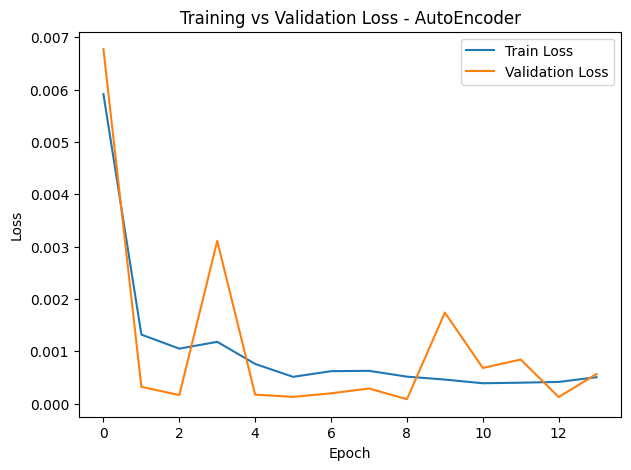


AutoEncoder final train loss: 0.0005050977342762053
AutoEncoder final val loss: 0.0005668791709467769


In [8]:

input_dim = X_train_ae.shape[1]

input_layer = Input(shape=(input_dim,))

encoded = Dense(128, activation="relu")(input_layer)
encoded = Dense(64, activation="relu")(encoded)
encoded = Dense(32, activation="relu")(encoded)

decoded = Dense(64, activation="relu")(encoded)
decoded = Dense(128, activation="relu")(decoded)
decoded = Dense(input_dim, activation="linear")(decoded)

autoencoder = Model(input_layer, decoded)

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

early_stop_ae = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_ae = autoencoder.fit(
    X_train_normal,
    X_train_normal,
    validation_split=0.2,
    epochs=30,
    batch_size=1024,
    shuffle=True,
    callbacks=[early_stop_ae],
    verbose=1
)


# AUTOENCODER OVERFITTING CHECK

plot_training_history(history_ae, "AutoEncoder")

print("\nAutoEncoder final train loss:", history_ae.history["loss"][-1])
print("AutoEncoder final val loss:", history_ae.history["val_loss"][-1])

In [9]:
# ===============================
# AUTOENCODER THRESHOLD FROM TRAIN NORMAL
# ===============================

train_reconstructions = autoencoder.predict(X_train_normal)

train_mse = np.mean(
    np.power(X_train_normal.values - train_reconstructions, 2),
    axis=1
)

threshold_ae = np.percentile(train_mse, 99)

print("AutoEncoder threshold:", threshold_ae)

158861/158861 ━━━━━━━━━━━━━━━━━━━━ 146s 918us/step
AutoEncoder threshold: 0.0005491069


In [10]:
# AUTOENCODER PREDICTION

test_reconstructions = autoencoder.predict(X_test)

test_mse = np.mean(
    np.power(X_test.values - test_reconstructions, 2),
    axis=1
)

y_pred_ae = (test_mse > threshold_ae).astype(int)

39767/39767 ━━━━━━━━━━━━━━━━━━━━ 38s 960us/step


Hàm đánh giá

Tính toán các chỉ số

In [11]:
def calculate_metrics(y_true, y_pred, y_prob=None):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    specificity = tn / (tn + fp)
    fallout = fp / (fp + tn)

    roc_auc = None
    pr_auc = None

    if y_prob is not None:
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        roc_auc = auc(fpr, tpr)
        pr_auc = average_precision_score(y_true, y_prob)

    print(classification_report(y_true, y_pred, digits=4))

    metrics = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "Specificity": specificity,
        "Fall-out": fallout,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc
    }

    return metrics

Vẽ ma trận nhầm lẫn và PLOT ROC CURVE + AUC

In [12]:
def plot_confusion_matrix(model_name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

In [13]:
def plot_roc_curve(model_name, y_true, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name}")
    plt.legend(loc="lower right")
    plt.show()

In [14]:
def plot_pr_curve(model_name, y_true, y_prob):
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)

    plt.figure(figsize=(7, 6))
    plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.4f}")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve - {model_name}")
    plt.legend(loc="lower left")
    plt.show()

Đánh giá model


MODEL: FFNN
              precision    recall  f1-score   support

           0     0.9999    0.9979    0.9989   1270881
           1     0.3563    0.9105    0.5122      1643

    accuracy                         0.9978   1272524
   macro avg     0.6781    0.9542    0.7555   1272524
weighted avg     0.9991    0.9978    0.9982   1272524

Accuracy       : 0.9978
Precision      : 0.3563
Recall         : 0.9105
F1-score       : 0.5122
Specificity    : 0.9979
Fall-out       : 0.0021
ROC-AUC        : 0.9988
PR-AUC         : 0.8259


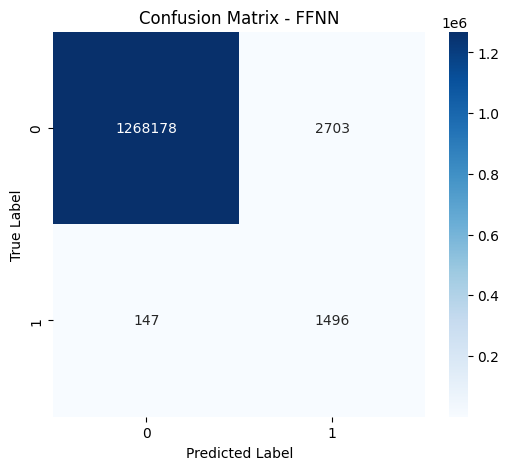

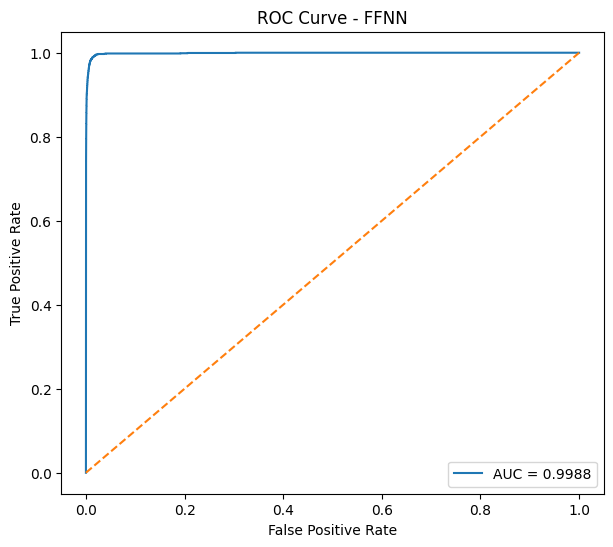

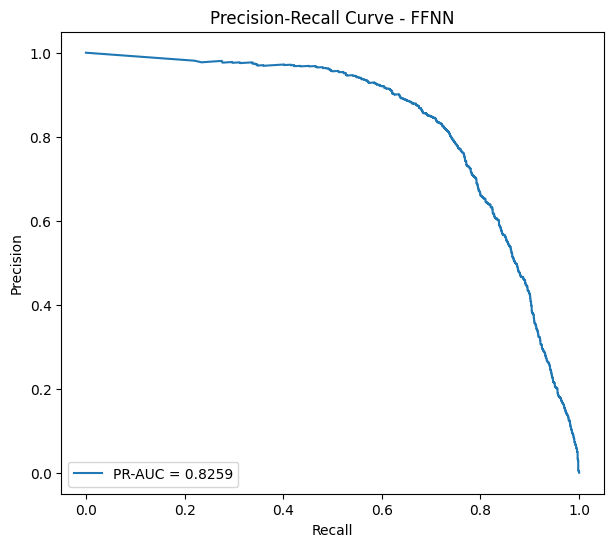

In [15]:
results = {}

print("\n" + "="*60)
print("MODEL: FFNN")
print("="*60)

metrics_ffnn = calculate_metrics(
    y_true=y_test,
    y_pred=y_pred_ffnn,
    y_prob=y_prob_ffnn
)

results["FFNN"] = metrics_ffnn

for key, value in metrics_ffnn.items():
    if value is not None:
        print(f"{key:<15}: {value:.4f}")

plot_confusion_matrix("FFNN", y_test, y_pred_ffnn)
plot_roc_curve("FFNN", y_test, y_prob_ffnn)
plot_pr_curve("FFNN", y_test, y_prob_ffnn)


MODEL: AutoEncoder
              precision    recall  f1-score   support

           0     0.9995    0.9900    0.9948   1270881
           1     0.0749    0.6233    0.1337      1643

    accuracy                         0.9896   1272524
   macro avg     0.5372    0.8066    0.5642   1272524
weighted avg     0.9983    0.9896    0.9936   1272524

Accuracy       : 0.9896
Precision      : 0.0749
Recall         : 0.6233
F1-score       : 0.1337
Specificity    : 0.9900
Fall-out       : 0.0100
ROC-AUC        : 0.9500
PR-AUC         : 0.3194


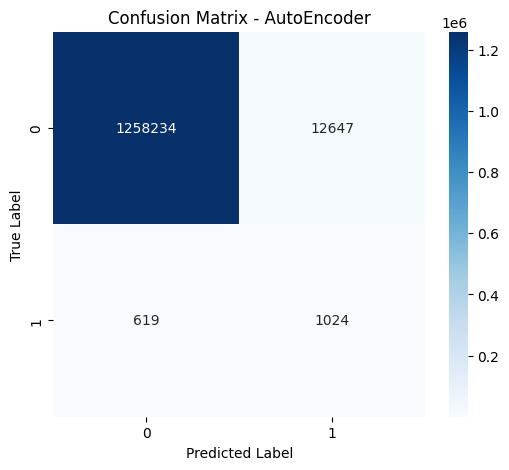

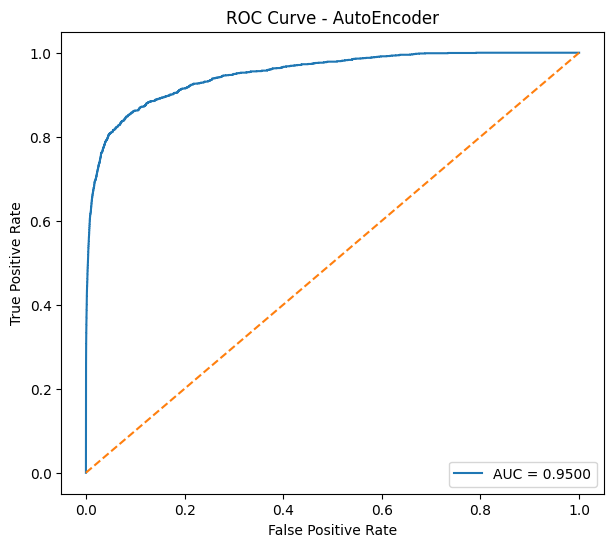

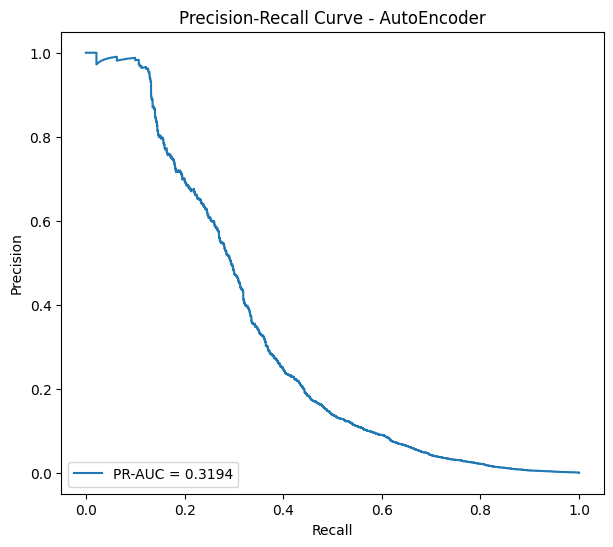

In [16]:
print("\n" + "="*60)
print("MODEL: AutoEncoder")
print("="*60)

metrics_ae = calculate_metrics(
    y_true=y_test,
    y_pred=y_pred_ae,
    y_prob=test_mse
)

results["AutoEncoder"] = metrics_ae

for key, value in metrics_ae.items():
    if value is not None:
        print(f"{key:<15}: {value:.4f}")

plot_confusion_matrix("AutoEncoder", y_test, y_pred_ae)
plot_roc_curve("AutoEncoder", y_test, test_mse)
plot_pr_curve("AutoEncoder", y_test, test_mse)

So sánh các model

In [17]:
results_df = pd.DataFrame(results).T

print("\nMODEL COMPARISON")
display(results_df)

final_results = results_df.sort_values(
    by="F1-score",
    ascending=False
)

print("\nFINAL SORTED RESULTS")
display(final_results)

best_model_name = final_results.index[0]
print("Best model:", best_model_name)


MODEL COMPARISON


,Accuracy,Precision,Recall,F1-score,Specificity,Fall-out,ROC-AUC,PR-AUC
FFNN,0.997760,0.356275,0.91053,0.512153,0.997873,0.002127,0.998809,0.825933
AutoEncoder,0.989575,0.074903,0.62325,0.133734,0.990049,0.009951,0.950027,0.319434



FINAL SORTED RESULTS


,Accuracy,Precision,Recall,F1-score,Specificity,Fall-out,ROC-AUC,PR-AUC
FFNN,0.997760,0.356275,0.91053,0.512153,0.997873,0.002127,0.998809,0.825933
AutoEncoder,0.989575,0.074903,0.62325,0.133734,0.990049,0.009951,0.950027,0.319434


Best model: FFNN


Lưu model

In [18]:
SAVE_DIR = "../model/saved_models"

os.makedirs(SAVE_DIR, exist_ok=True)

results_df.to_csv(f"{SAVE_DIR}/model_results.csv")
final_results.to_csv(f"{SAVE_DIR}/final_sorted_results.csv")

ffnn_model.save(f"{SAVE_DIR}/ffnn.h5")
autoencoder.save(f"{SAVE_DIR}/autoencoder.h5")

joblib.dump(threshold_ffnn, f"{SAVE_DIR}/ffnn_threshold.pkl")
joblib.dump(threshold_ae, f"{SAVE_DIR}/autoencoder_threshold.pkl")

with open(f"{SAVE_DIR}/best_model_name.txt", "w") as f:
    f.write(best_model_name)

if best_model_name == "FFNN":
    ffnn_model.save(f"{SAVE_DIR}/best_model.h5")
elif best_model_name == "AutoEncoder":
    autoencoder.save(f"{SAVE_DIR}/best_model.h5")

print("Models saved successfully!")

Models saved successfully!
